In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.neural_network import MLPClassifier

In [5]:
df = pd.read_csv('../data/dataCleaned.csv')

print(df.shape)
df.head()

(96125, 9)


,model,year,price,transmission,mileage,fuelType,mpg,engineSize,brand
0,A1,2017,12500,Manual,15735,Petrol,55.4,1.4,Audi
1,A6,2016,16500,Automatic,36203,Diesel,64.2,2.0,Audi
2,A1,2016,11000,Manual,29946,Petrol,55.4,1.4,Audi
3,A4,2017,16800,Automatic,25952,Diesel,67.3,2.0,Audi
4,A3,2019,17300,Manual,1998,Petrol,49.6,1.0,Audi


In [6]:
bins = [0, 10000, 20000, 100000]
labels = [0, 1, 2]

df['price_category'] = pd.cut(df['price'], bins=bins, labels=labels).astype(int)

df['price_category'].value_counts()

price_category
1    46472
0    24981
2    24672
Name: count, dtype: int64

In [7]:
df_ml=df.copy()

#car age
df_ml['car_age']= 2020 - df_ml['year']
df_ml = df_ml.drop(columns=['year'])

#log transfrom mileage
df['mileage']= np.log1p(df_ml['mileage'])

#one hot encoding
df_ml = pd.get_dummies(df_ml, columns=['brand', 'model', 'fuelType', 'transmission'], drop_first=False)

df_ml.head()

,price,mileage,mpg,engineSize,price_category,car_age,brand_Audi,brand_Bmw,brand_Ford,brand_Hyundai,...,model_180,model_200,model_220,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Petrol,transmission_Automatic,transmission_Manual,transmission_Semi-Auto
0,12500,15735,55.4,1.4,1,3,True,False,False,False,...,False,False,False,False,False,False,True,False,True,False
1,16500,36203,64.2,2.0,1,4,True,False,False,False,...,False,False,False,True,False,False,False,True,False,False
2,11000,29946,55.4,1.4,1,4,True,False,False,False,...,False,False,False,False,False,False,True,False,True,False
3,16800,25952,67.3,2.0,1,3,True,False,False,False,...,False,False,False,True,False,False,False,True,False,False
4,17300,1998,49.6,1.0,1,1,True,False,False,False,...,False,False,False,False,False,False,True,False,True,False


In [8]:
X = df_ml.drop(columns=['price', 'price_category'])
y = df_ml['price_category']

print(X.shape, y.shape)

(96125, 213) (96125,)


In [9]:
X = df_ml.drop(columns=['price', 'price_category'])
y = df_ml['price_category']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
nn_small =MLPClassifier(
    hidden_layer_sizes=(32,),
    activation='relu',
    max_iter=300,
    random_state=42
)

nn_small.fit(X_train, y_train)

pred_small = nn_small.predict(X_test)
print("Small NN iterations used:", nn_small.n_iter_)

Small NN iterations used: 190


In [15]:
nn_medium =MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=400,
    random_state=42
)

nn_medium.fit(X_train, y_train)

pred_medium = nn_medium.predict(X_test)
print("medium NN iterations used:", nn_medium.n_iter_)

medium NN iterations used: 312


In [16]:
nn_large =MLPClassifier(
    hidden_layer_sizes=(128,64,32),
    activation='relu',
    max_iter=400,
    random_state=42
)

nn_large.fit(X_train, y_train)

pred_large = nn_large.predict(X_test)
print("large NN iterations used:", nn_large.n_iter_)

large NN iterations used: 323


In [17]:
results = []

models = {
    "Small (32)": pred_small,
    "Medium (64,32)":pred_medium,
    "Large (128,64,32)": pred_large
}

for name,pred in models.items():

    results.append({
        "Architecture": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, average='weighted'),
        "Recall": recall_score(y_test, pred, average='weighted'),
        "F1": f1_score(y_test, pred, average='weighted'),
    })

results_df = pd.DataFrame(results)

results_df

,Architecture,Accuracy,Precision,Recall,F1
0,Small (32),0.909233,0.909838,0.909233,0.909223
1,"Medium (64,32)",0.910689,0.910922,0.910689,0.910641
2,"Large (128,64,32)",0.910481,0.910533,0.910481,0.910484


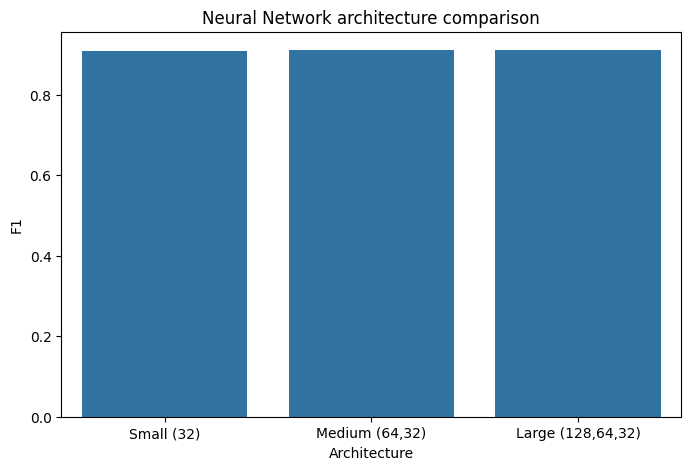

In [19]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x='Architecture',
    y='F1'
)

plt.title("Neural Network architecture comparison")
plt.show()

In [20]:
param_grid = {
    'hidden_layer_sizes': [
        (32,),
        (64,32),
        (128,64,32)
    ],
    'activation': [
        'relu',
        'tanh'
    ],
    'alpha': [
        0.0001,
        0.001
    ]
}

grid = GridSearchCV(
    MLPClassifier(
        max_iter=300,
        random_state=42
    ),
    param_grid,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1
)

grid.fit(X_train,y_train)

print(grid.best_params_)
print(grid.best_score_)

{'activation': 'tanh', 'alpha': 0.001, 'hidden_layer_sizes': (32,)}
0.9099671226206683


In [21]:
best_nn = grid.best_estimator_

best_pred = best_nn.predict(X_test)

In [24]:
print(classification_report(
    y_test,
    best_pred,
    target_names=[
        'Budget',
        'Mid-Range',
        'Premium'
    ]
))

              precision    recall  f1-score   support

      Budget       0.93      0.89      0.91      4996
   Mid-Range       0.90      0.92      0.91      9295
     Premium       0.92      0.92      0.92      4934

    accuracy                           0.91     19225
   macro avg       0.92      0.91      0.91     19225
weighted avg       0.91      0.91      0.91     19225



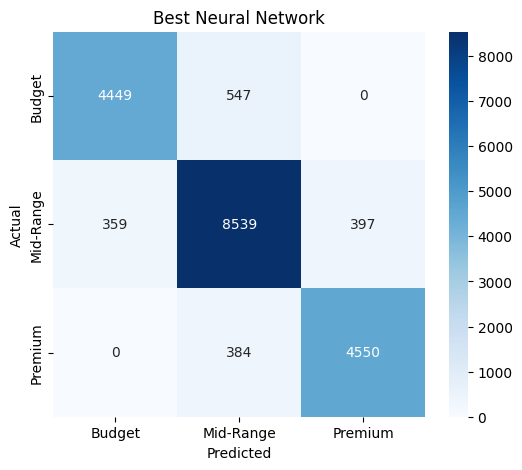

In [25]:
cm = confusion_matrix(
    y_test,
    best_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Budget','Mid-Range','Premium'],
    yticklabels=['Budget','Mid-Range','Premium']
)

plt.title('Best Neural Network')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [26]:
final_results = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1'
    ],
    'Value': [
        accuracy_score(y_test,best_pred),
        precision_score(y_test,best_pred,average='weighted'),
        recall_score(y_test,best_pred,average='weighted'),
        f1_score(y_test,best_pred,average='weighted')
    ]
})

final_results

,Metric,Value
0,Accuracy,0.912250
1,Precision,0.912469
2,Recall,0.912250
3,F1,0.912234
